In [1]:
import model as m
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
import numpy as np

### Parameter Values

Controllable Parameters

name | units | description
--- | --- | --- 
$K$ | `f` | carrying capacity of frog saunas, a function of $u_1$
$\xi$ | `1 / t` | rate of transfer into antifungal treatment, a function of $u_2$

Constant Parameters

name | units | description
--- | --- | --- 
$\alpha$ | `1 / f / t` | infection rate from living hosts
$\beta$ | `1 / t` | death rate from disease
$\gamma$ | `1 / f / t` | rate that frogs leave sauna
$\zeta$ | `1 / t` | rate of transfer to heat treatment
$\eta$ | `1` (unitless) | success rate of antifungal bath treatment

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.005e-01 ...  4.995e+02  5.000e+02]
        y: [[ 4.000e+03  1.441e+02 ...  5.010e-08  4.878e-08]
            [ 4.000e+03  7.823e+03 ...  5.422e+01  5.395e+01]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  3.321e+01 ...  7.946e+03  7.946e+03]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1646
     njev: 0
      nlu: 0

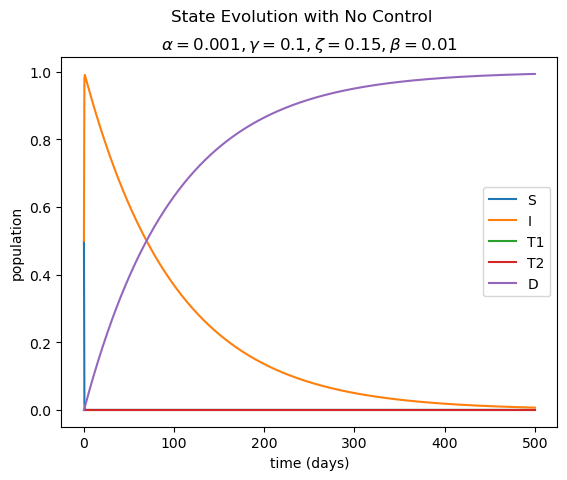

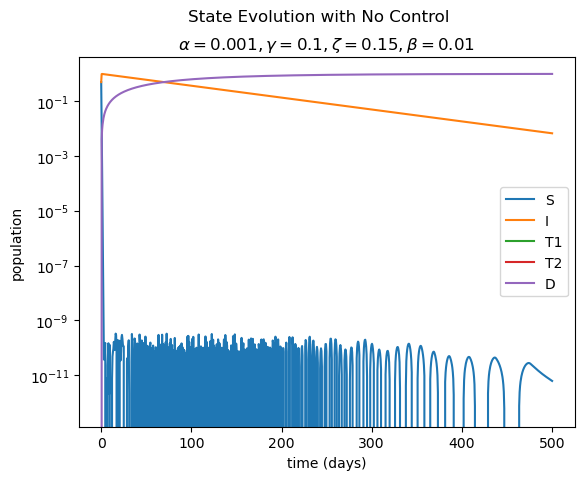

In [ ]:
# No Controls, autonomous evolution

tsteps = 1000

# params
y_init = np.array([4000, 4000, 0, 0, 0]) # 4k for y_init susceptible and infected
alpha, gamma, zeta, beta = .001, 0.1, 0.15, 0.01 # central time average parameter estimates
K, eta, xi = lambda u1: 365 * u1 / 2, lambda u2: 1, lambda u2, I: u2 / I / 100 # control functions
control1 = 0, 0 # we have no frog hotels
control2 = K, eta, xi # other parameters

# solve for tf days
t0, tf = 0, 500
sol = solve_ivp(
    m.model_equation,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=[control1, control2, alpha, gamma, zeta, beta]
    )

display(sol)

# graph each compartment
plt.plot(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.plot(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.plot(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.plot(sol.t, sol.y[3] / np.sum(y_init), label="T2")
plt.plot(sol.t, sol.y[4] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with No Control")
plt.title(fr"$\alpha = {alpha}, \gamma = {gamma}, \zeta = {zeta}, \beta = {beta}$")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

plt.show()

# log log

plt.semilogy(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.semilogy(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.semilogy(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="T2")
plt.semilogy(sol.t, sol.y[4] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with No Control")
plt.title(fr"$\alpha = {alpha}, \gamma = {gamma}, \zeta = {zeta}, \beta = {beta}$")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.005e-01 ...  4.995e+02  5.000e+02]
        y: [[ 4.000e+03  1.597e+02 ...  1.561e+02  1.561e+02]
            [ 4.000e+03  7.245e+03 ...  4.116e+02  4.108e+02]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  3.179e+01 ...  6.556e+03  6.558e+03]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1280
     njev: 0
      nlu: 0

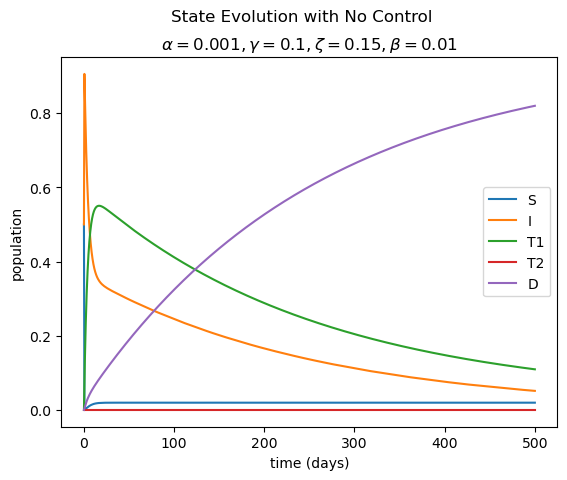

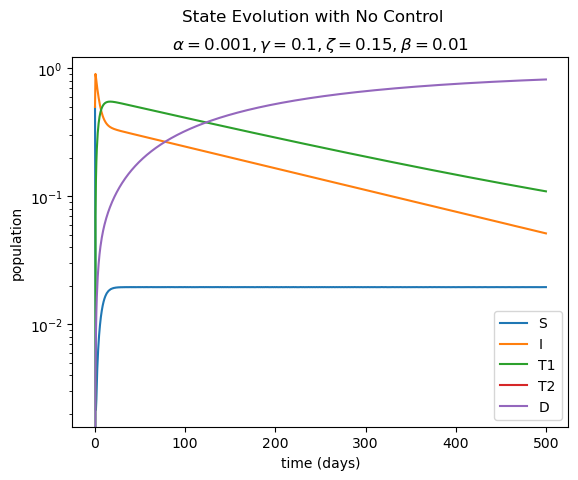

In [4]:
# $10 / day in Frog Sauna, autonomous evolution

tsteps = 1000

# params
y_init = np.array([4000, 4000, 0, 0, 0]) # 4k for y_init susceptible and infected
alpha, gamma, zeta, beta = .001, 0.1, 0.15, 0.01 # central time average parameter estimates
K, eta, xi = lambda u1: 365 * u1 / 2, lambda u2: 1, lambda u2, I: u2 / I / 100 # control functions
control1 = 10, 0 # we have some frog hotels
control2 = K, eta, xi # other parameters

# solve for tf days
t0, tf = 0, 500
sol = solve_ivp(
    m.model_equation,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=[control1, control2, alpha, gamma, zeta, beta]
    )

display(sol)

# graph each compartment
plt.plot(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.plot(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.plot(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.plot(sol.t, sol.y[3] / np.sum(y_init), label="T2")
plt.plot(sol.t, sol.y[4] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with No Control")
plt.title(fr"$\alpha = {alpha}, \gamma = {gamma}, \zeta = {zeta}, \beta = {beta}$")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

plt.show()

# log log

plt.semilogy(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.semilogy(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.semilogy(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="T2")
plt.semilogy(sol.t, sol.y[4] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with No Control")
plt.title(fr"$\alpha = {alpha}, \gamma = {gamma}, \zeta = {zeta}, \beta = {beta}$")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

  message: Required step size is less than spacing between numbers.
  success: False
   status: -1
        t: [ 0.000e+00  5.005e-01 ...  4.324e+02  4.329e+02]
        y: [[ 4.000e+03  1.447e+02 ...  1.129e+03  2.237e+03]
            [ 4.000e+03  7.818e+03 ... -9.434e+02 -2.044e+03]
            ...
            [ 0.000e+00  3.938e+00 ...  9.998e+00  9.999e+00]
            [ 0.000e+00  3.319e+01 ...  7.805e+03  7.798e+03]]
      sol: None
 t_events: None
 y_events: None
     nfev: 2318
     njev: 0
      nlu: 0

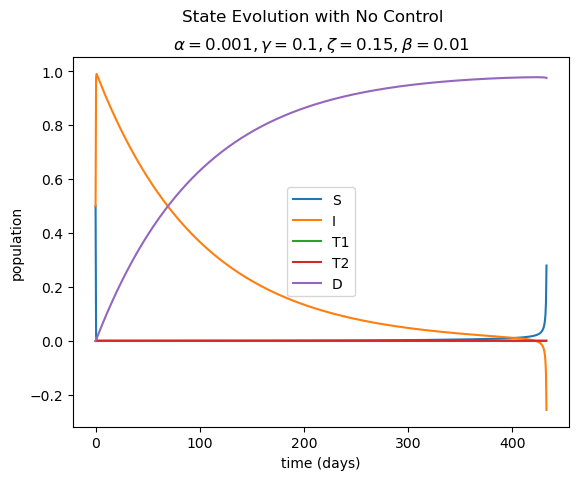

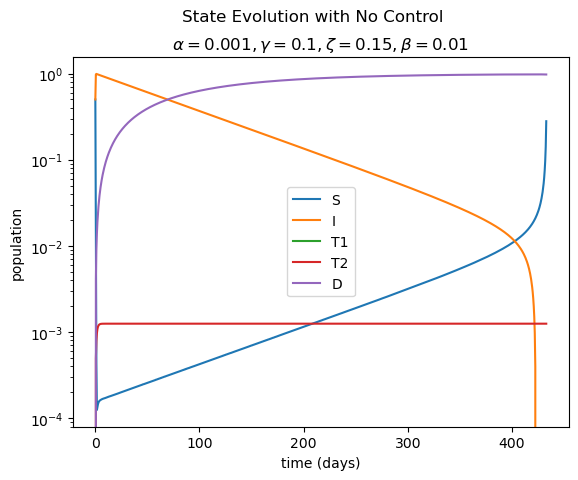

In [5]:
# $1000 / day in Frog treatment, autonomous evolution

tsteps = 1000

# params
y_init = np.array([4000, 4000, 0, 0, 0]) # 4k for y_init susceptible and infected
alpha, gamma, zeta, beta = .001, 0.1, 0.15, 0.01 # central time average parameter estimates
K, eta, xi = lambda u1: 365 * u1 / 2, lambda u2: 1, lambda u2, I: u2 / I / 100 # control functions
control1 = 0, 1000 # we have some frog bathers
control2 = K, eta, xi # other parameters

# solve for tf days
t0, tf = 0, 500
sol = solve_ivp(
    m.model_equation,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=[control1, control2, alpha, gamma, zeta, beta]
    )

display(sol)

# graph each compartment
plt.plot(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.plot(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.plot(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.plot(sol.t, sol.y[3] / np.sum(y_init), label="T2")
plt.plot(sol.t, sol.y[4] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with No Control")
plt.title(fr"$\alpha = {alpha}, \gamma = {gamma}, \zeta = {zeta}, \beta = {beta}$")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

plt.show()

# log log

plt.semilogy(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.semilogy(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.semilogy(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="T2")
plt.semilogy(sol.t, sol.y[4] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with No Control")
plt.title(fr"$\alpha = {alpha}, \gamma = {gamma}, \zeta = {zeta}, \beta = {beta}$")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()